# Medical Data Analysis with Pandas

This notebook is designed to help you analyze medical datasets using Pandas. Follow the instructions in each section to solve the problems by filling in the code where indicated.

## Problem 1: ICU Patient Monitoring

### Scenario:
You are analyzing data collected from ICU (Intensive Care Unit) patient monitors. The goal is to identify any patterns or anomalies in the patient's vital signs to assist in improving patient care.

### Dataset:
- `patient_id`: Unique identifier for each patient
- `timestamp`: Time when the vital sign was recorded
- `heart_rate`: Patient's heart rate (beats per minute)
- `blood_pressure`: Patient's blood pressure (mmHg)
- `respiratory_rate`: Patient's respiratory rate (breaths per minute)
- `oxygen_saturation`: Patient's oxygen saturation (%)

In [81]:
#  Download data from the web
# !wget https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/icu_data.csv
# !wget https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/bed_occupancy.csv
# !wget https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/clinical_trial.csv
# !wget https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/clinical_tests.csv
# !wget https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/satisfaction_survey.csv
# !wget https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/medication_side_effects.csv

--2024-08-19 13:18:47--  https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/icu_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 289021 (282K) [text/plain]
Saving to: ‘icu_data.csv.2’

icu_data.csv.2      100%[===================>] 282.25K  --.-KB/s    in 0.04s   

2024-08-19 13:18:47 (6.72 MB/s) - ‘icu_data.csv.2’ saved [289021/289021]

--2024-08-19 13:18:47--  https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/bed_occupancy.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Leng

In [68]:
# Load the ICU dataset
# TODO: Replace 'icu_data.csv' with the actual file name
import pandas as pd
icu_df = pd.read_csv('https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/icu_data.csv')
icu_df.head()

,patient_id,timestamp,heart_rate,blood_pressure,respiratory_rate,oxygen_saturation
0,1,2024-08-20 06:26:24.454391,94,111,20,97.992708
1,1,2024-08-19 21:40:24.454391,109,83,13,92.882682
2,1,2024-08-20 02:47:24.454391,92,120,12,89.867010
3,1,2024-08-19 21:09:24.454391,81,140,18,88.587073
4,1,2024-08-19 17:20:24.454391,89,98,20,99.993459


### Task 1: Identify Anomalies in Vital Signs
Identify any patients with anomalous vital signs (e.g., heart rate > 100 bpm, blood pressure < 90/60 mmHg, oxygen saturation < 90%).

In [69]:
# TODO: Identify anomalies in vital signs
anomalies = icu_df[(icu_df['heart_rate'] > 100) | 
                 (icu_df['blood_pressure'] < 90) | 
                 (icu_df['oxygen_saturation'] < 90)]
anomalies.head()

,patient_id,timestamp,heart_rate,blood_pressure,respiratory_rate,oxygen_saturation
1,1,2024-08-19 21:40:24.454391,109,83,13,92.882682
2,1,2024-08-20 02:47:24.454391,92,120,12,89.867010
3,1,2024-08-19 21:09:24.454391,81,140,18,88.587073
5,1,2024-08-20 01:23:24.454391,110,91,18,98.741734
6,1,2024-08-19 20:25:24.454391,107,125,18,90.914683


### Task 2: Average Vital Signs by Patient
Calculate the average heart rate, blood pressure, and oxygen saturation for each patient.

In [70]:
# TODO: Calculate average vital signs by patient
avg_vitals = icu_df.groupby('patient_id')[['heart_rate', 'blood_pressure', 'oxygen_saturation']].mean()
avg_vitals.head()

,heart_rate,blood_pressure,oxygen_saturation
patient_id,,,
1,88.58,106.82,94.776106
2,90.12,109.66,93.489247
3,86.80,111.42,93.845065
4,89.98,107.20,94.934324
5,89.56,108.18,93.685156


### Task 3: Time Series Plot for a Selected Patient
Choose a patient and plot their heart rate and blood pressure over time.

/tmp/ipykernel_115615/2230766767.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_data["timestamp"] = pd.to_datetime(patient_data["timestamp"])


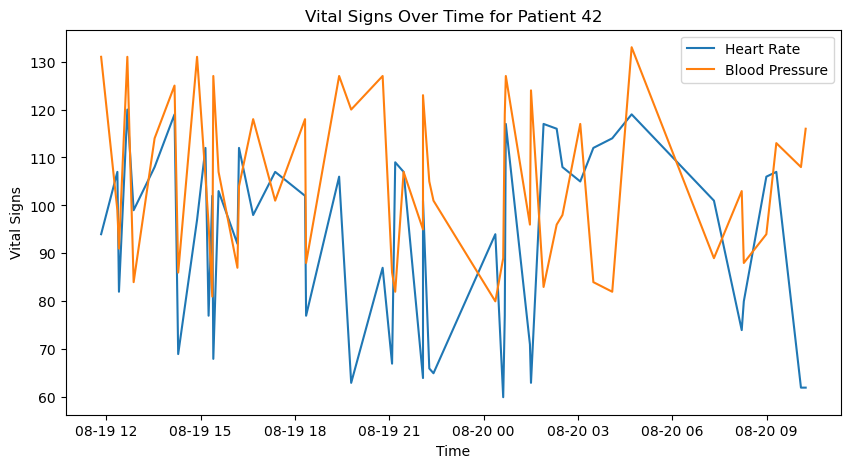

In [71]:
# TODO: Plot time series for a selected patient
import matplotlib.pyplot as plt
patient_id = 42  # Replace with a valid patient ID
patient_data = icu_df[icu_df['patient_id'] == patient_id]

# Time series analysis set up time data
patient_data["timestamp"] = pd.to_datetime(patient_data["timestamp"])
# Sort the data by timestamp
patient_data = patient_data.sort_values("timestamp")


plt.figure(figsize=(10, 5))
plt.plot(patient_data['timestamp'], patient_data['heart_rate'], label='Heart Rate')
plt.plot(patient_data['timestamp'], patient_data['blood_pressure'], label='Blood Pressure')
plt.xlabel('Time')
plt.ylabel('Vital Signs')
plt.title(f'Vital Signs Over Time for Patient {patient_id}')
plt.legend()
plt.show()

## Problem 2: Analyzing Clinical Test Results

### Scenario:
You are working with a dataset that contains the results of various clinical tests performed on patients. The goal is to analyze the data to identify trends and potential areas of concern.

### Dataset:
- `patient_id`: Unique identifier for each patient
- `test_name`: Name of the test performed
- `test_result`: Result of the test
- `reference_range`: The normal range for the test result
- `test_date`: Date when the test was performed

In [72]:
# Load the clinical test results dataset
# TODO: Replace 'clinical_tests.csv' with the actual file name
clinical_tests_df = pd.read_csv('https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/clinical_tests.csv')
clinical_tests_df.head()

,patient_id,test_name,test_result,reference_range,test_date
0,1,Glucose,132.169655,70-140,2024-09-02
1,1,Cholesterol,157.178940,100-200,2024-09-08
2,1,Hemoglobin,21.309902,12-16,2024-09-18
3,1,WBC,5.244117,4-11,2024-08-22
4,1,RBC,3.657151,4.5-6,2024-09-07


### Task 1: Identify Abnormal Test Results
Identify any tests where the result is outside the normal reference range.

In [73]:
# TODO: Identify abnormal test results
clinical_tests_df['abnormal'] = False
# for loop to iterate through the rows of the DataFrame
for index, row in clinical_tests_df.iterrows():
    test_result = row['test_result']
    reference_range = row['reference_range']
    reference_range_low = float(reference_range.split('-')[0])
    reference_range_high = float(reference_range.split('-')[1])
    if test_result < reference_range_low or test_result > reference_range_high:
        clinical_tests_df.at[index, 'abnormal'] = True

# without for loop / using pandas
clinical_tests_df['abnormal'] = (clinical_tests_df['test_result'] < clinical_tests_df['reference_range'].str.split('-').str[0].astype(float)) | (clinical_tests_df['test_result'] > clinical_tests_df['reference_range'].str.split('-').str[1].astype(float))

# abnormal test results only 
abnormal_tests = clinical_tests_df[clinical_tests_df['abnormal'] == True]
abnormal_tests.head()

,patient_id,test_name,test_result,reference_range,test_date,abnormal
2,1,Hemoglobin,21.309902,12-16,2024-09-18,True
4,1,RBC,3.657151,4.5-6,2024-09-07,True
9,2,RBC,3.518887,4.5-6,2024-09-11,True
10,3,Glucose,174.165506,70-140,2024-09-18,True
11,3,Cholesterol,250.199126,100-200,2024-08-19,True


### Task 2: Analyze Test Trends Over Time
Choose a specific test and analyze how its results have changed over time for all patients.

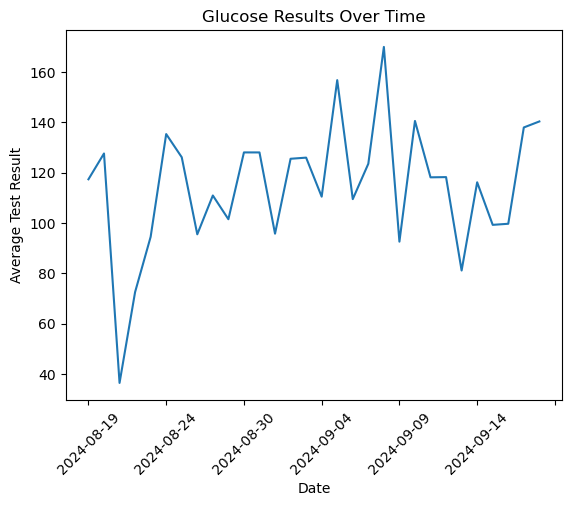

In [74]:
# TODO: Analyze test trends over time
test_name = 'Glucose'  # Replace with a specific test name
test_trends = clinical_tests_df[clinical_tests_df['test_name'] == test_name]
test_trends.groupby('test_date')['test_result'].mean().plot(title=f'{test_name} Results Over Time')
plt.xlabel('Date')
# rotate the x-axis labels for better readability
plt.xticks(rotation=45)
plt.ylabel('Average Test Result')
plt.show()

## Problem 3: Predicting Hospital Bed Occupancy Rates

### Scenario:
You are tasked with analyzing historical data on hospital bed occupancy to predict future occupancy rates. The goal is to help the hospital manage its resources more effectively by identifying trends and patterns in bed occupancy.

### Dataset:
- `date`: The date of the observation
- `total_beds`: The total number of beds available in the hospital
- `occupied_beds`: The number of beds occupied on a given day
- `admissions`: The number of new patient admissions on a given day
- `discharges`: The number of patient discharges on a given day

In [75]:
# Load the hospital bed occupancy dataset
# TODO: Replace 'bed_occupancy.csv' with the actual file name
bed_df = pd.read_csv('https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/bed_occupancy.csv')
bed_df.head()

,date,total_beds,occupied_beds,admissions,discharges
0,2024-08-19,200,196,17,12
1,2024-08-20,200,168,11,15
2,2024-08-21,200,172,12,11
3,2024-08-22,200,136,30,20
4,2024-08-23,200,160,21,11


### Task 1: Calculate the Daily Occupancy Rate
Calculate the daily occupancy rate as a percentage of total beds occupied.

In [76]:
# TODO: Calculate the daily occupancy rate
bed_df['occupancy_rate'] = (bed_df['occupied_beds'] / bed_df['total_beds']) * 100
bed_df[['date', 'occupancy_rate']].head()

,date,occupancy_rate
0,2024-08-19,98.0
1,2024-08-20,84.0
2,2024-08-21,86.0
3,2024-08-22,68.0
4,2024-08-23,80.0


### Task 2: Identify Trends in Bed Occupancy
Are there certain times of the year when occupancy rates are higher?

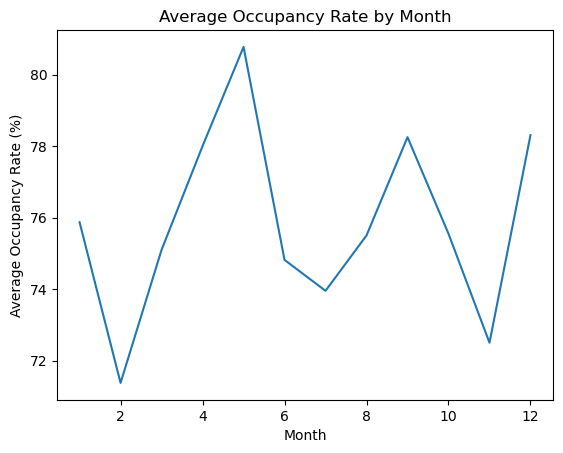

In [77]:
# TODO: Identify trends in bed occupancy
bed_df['date'] = pd.to_datetime(bed_df['date'])
bed_df['month'] = bed_df['date'].dt.month
monthly_occupancy = bed_df.groupby('month')['occupancy_rate'].mean()
monthly_occupancy.plot(title='Average Occupancy Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Occupancy Rate (%)')
plt.show()

## Problem 4: Patient Satisfaction Survey Analysis

### Scenario:
You have access to a dataset containing patient satisfaction survey results. Your goal is to analyze the data to identify key factors that contribute to high or low satisfaction scores.

### Dataset:
- `patient_id`: Unique identifier for each patient
- `age`: Age of the patient
- `gender`: Gender of the patient (Male/Female)
- `department`: The hospital department where the patient was treated
- `satisfaction_score`: Patient's satisfaction score (1-10)
- `wait_time`: The amount of time (in minutes) the patient waited before being seen by a doctor
- `treatment_outcome`: The patient's reported outcome after treatment (Improved, No Change, Worsened)

In [78]:
# Load the patient satisfaction survey dataset
# TODO: Replace 'satisfaction_survey.csv' with the actual file name
satisfaction_df = pd.read_csv('https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/satisfaction_survey.csv')
satisfaction_df.head()

,patient_id,age,gender,department,satisfaction_score,wait_time,treatment_outcome
0,1,36,Female,Pediatrics,7,80,Improved
1,2,29,Male,Cardiology,2,5,No Change
2,3,33,Female,Cardiology,4,12,Improved
3,4,83,Female,Orthopedics,2,54,No Change
4,5,76,Male,Pediatrics,6,14,Improved


### Task 1: Correlation Analysis
Determine which factors are most correlated with high satisfaction scores.

In [79]:
# TODO: Perform correlation analysis
# create dummy variables for categorical columns
satisfaction_df = pd.get_dummies(satisfaction_df)
correlations = satisfaction_df.corr()
correlations['satisfaction_score'].sort_values(ascending=False)

satisfaction_score             1.000000
department_Oncology            0.273786
treatment_outcome_No Change    0.107911
age                            0.067293
gender_Male                    0.054436
patient_id                     0.048401
wait_time                      0.016711
department_Cardiology          0.011216
department_Orthopedics         0.003534
treatment_outcome_Worsened    -0.006958
gender_Female                 -0.054436
treatment_outcome_Improved    -0.093481
department_Pediatrics         -0.127105
department_Neurology          -0.167292
Name: satisfaction_score, dtype: float64

## Problem 5: Tracking Medication Side Effects
### Scenario:
You are analyzing data from a study that tracked patients taking a new medication. The goal is to identify common side effects and determine if certain patient demographics are more susceptible.

### Dataset:
- `patient_id`: Unique identifier for each patient
- `age`: Age of the patient
- `gender`: Gender of the patient (Male/Female)
- `medication`: Name of the medication taken
- `side_effects`: List of side effects experienced by the patient (comma-separated if multiple)
- `severity`: Severity of side effects reported (Mild, Moderate, Severe)
- `duration`: Duration of medication taken (in days)

In [80]:
# Load the medication side effects dataset
# TODO: Replace 'medication_side_effects.csv' with the actual file name
side_effects_df = pd.read_csv('https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/medication_side_effects.csv')
side_effects_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'medication_side_effects.csv'

### Task 1: List the most common side effects
Identify the most frequently reported side effects among patients.

In [ ]:
# TODO: List the most common side effects
side_effects_df['side_effects'] = side_effects_df['side_effects'].str.split(', ')
all_side_effects = side_effects_df.explode('side_effects')
common_side_effects = all_side_effects['side_effects'].value_counts()
common_side_effects.head(10)

## Problem 6: Evaluating Treatment Outcomes in a Clinical Trial
### Scenario:
You are analyzing data from a clinical trial comparing the effectiveness of two treatments (Treatment A and Treatment B) for a chronic condition. The goal is to determine which treatment is more effective based on patient outcomes.

### Dataset:
- `patient_id`: Unique identifier for each patient
- `age`: Age of the patient
- `gender`: Gender of the patient (Male/Female)
- `treatment`: The treatment received (Treatment A or Treatment B)
- `baseline_severity`: Severity of the condition at the start of the trial (Mild, Moderate, Severe)
- `outcome`: Outcome after treatment (Improved, No Change, Worsened)
- `follow_up_duration`: Duration of follow-up after treatment (in days)

In [ ]:
# Load the clinical trial dataset
# TODO: Replace 'clinical_trial.csv' with the actual file name
trial_df = pd.read_csv('https://raw.githubusercontent.com/stawiskm/pythoncourse/student/Coding/Data/clinical_trial.csv')
trial_df.head()

### Task 1: Compare the effectiveness of Treatment A and Treatment B
Calculate the proportion of patients who showed improvement in each treatment group.

In [ ]:
# TODO: Compare the effectiveness of Treatment A and Treatment B
improvement_rates = trial_df.groupby('treatment')['outcome'].value_counts(normalize=True).unstack()
improvement_rates['Improved']

## Conclusion
In this notebook, you've analyzed several medical datasets using Pandas. These exercises covered a range of topics, from basic data manipulation to more advanced analyses. By completing these tasks, you've gained hands-on experience in working with real-world medical data.